Hypothesis 1: 

Null Hypothesis: There is no correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.

Alternate Hypothesis: There is a correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues

Data Cleaning

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

for col in [ethics_col] + political_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ethics concern: fill missing with column median
ethics_median = df[ethics_col].median()
df[ethics_col] = df[ethics_col].fillna(ethics_median)

# Political issues: fill missing with person's row average, fall back to column median if all blank
political_medians = df[political_cols].median()

for idx, row in df[political_cols].iterrows():
    answered = row.dropna()
    if len(answered) == 0:
        df.loc[idx, political_cols] = row.fillna(political_medians)
    elif row.isna().any():
        df.loc[idx, political_cols] = row.fillna(answered.mean())

# Round to integers
df[ethics_col] = df[ethics_col].round().astype(int)
for col in political_cols:
    df[col] = df[col].round().astype(int)

df.to_csv('data_cleaned_ethics_political.csv', index=False)

Cleaning: 
About 30% of the responses to the Political Issues were initally blank since the question was added late to the survey. For respondants that were missing values for each politics section we filled in the median. For respondants that left some of the responses blank, we filled in the missing response with their average across political questions.

About 30% of responses to the Ethics of AI question were initially blank since the question was added late to the survey. We cleaned this by filling in the the missing values with median 4. This is since there are no other similar questions to average for the response.

Visualization 1: Bar Chart

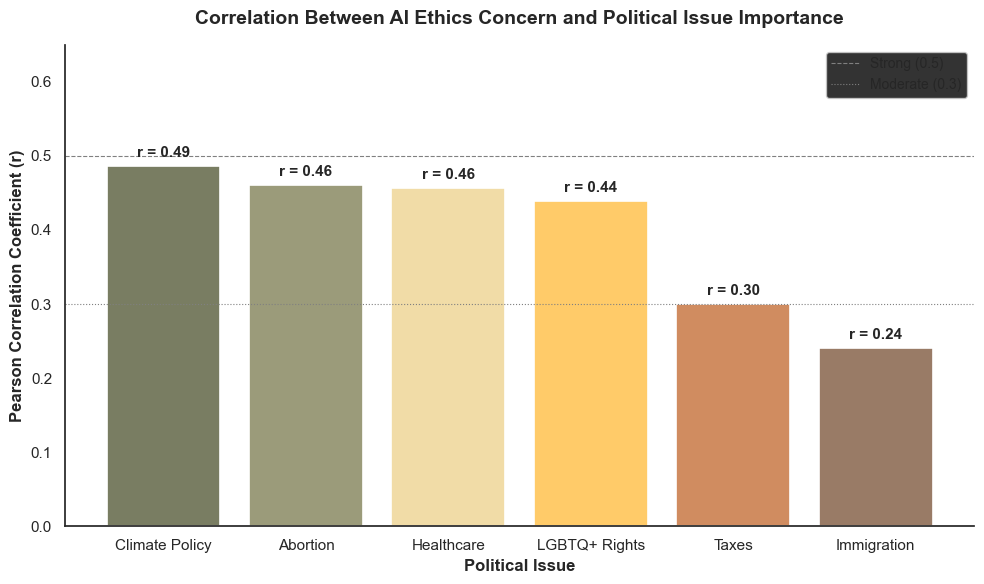

In [15]:
# I used the lab5-6 guide to make the bar graph, as well as claude
# for cleaning the data
import matplotlib.pyplot as plt

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']

corr_values = {label: df[ethics_col].corr(df[col]) for col, label in zip(political_cols, political_short)}
corr_series = pd.Series(corr_values).sort_values(ascending=False)

colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(corr_series.index, corr_series.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, corr_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008, f'r = {val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Strong (0.5)')
ax.axhline(y=0.3, color='gray', linestyle=':', linewidth=0.8, label='Moderate (0.3)')

ax.set_ylim(0, 0.65)
ax.set_xlabel('Political Issue', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax.set_title('Correlation Between AI Ethics Concern and Political Issue Importance', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Visualization 2: Box Plot Matrix

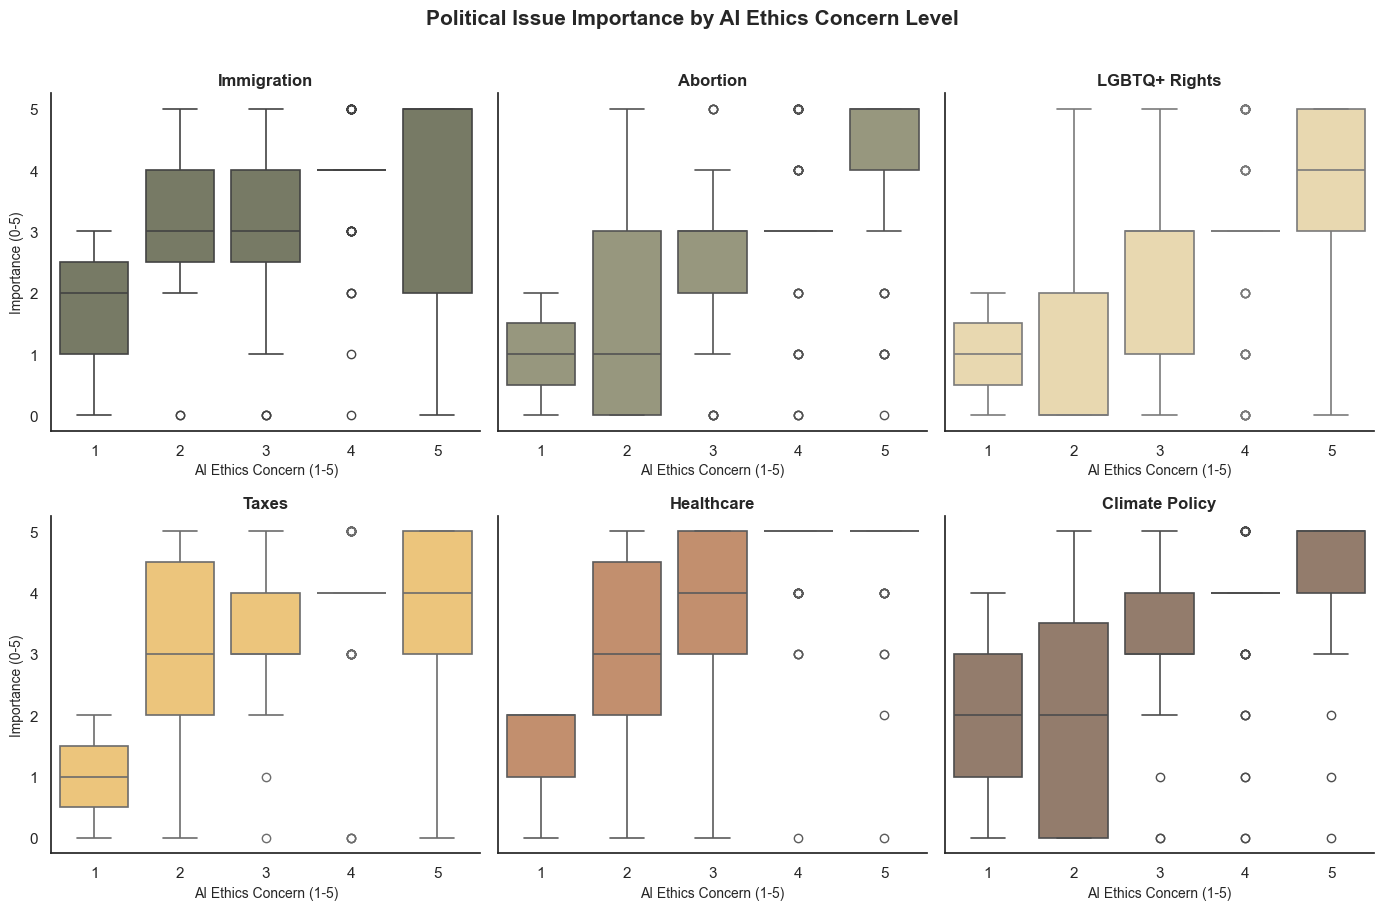

In [16]:
# I used the lab5-6 guide to make the box plot matrix as well as claude
# for cleaning the data
import seaborn as sns

df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']
colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(political_cols, political_short, colors)):
    sns.boxplot(data=df, x=ethics_col, y=col, ax=axes[i], color=color, linewidth=1.2)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('AI Ethics Concern (1-5)', fontsize=10)
    axes[i].set_ylabel('Importance (0-5)' if i % 3 == 0 else '', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Political Issue Importance by AI Ethics Concern Level', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Details:

Visualization 3: Ridge Graph

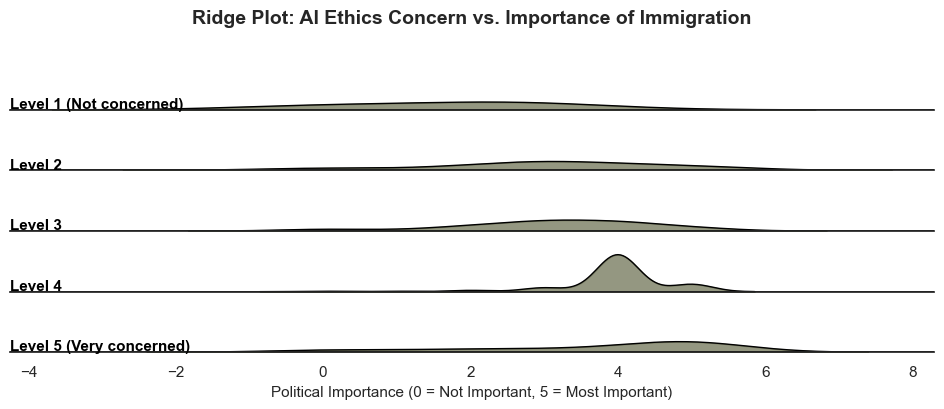

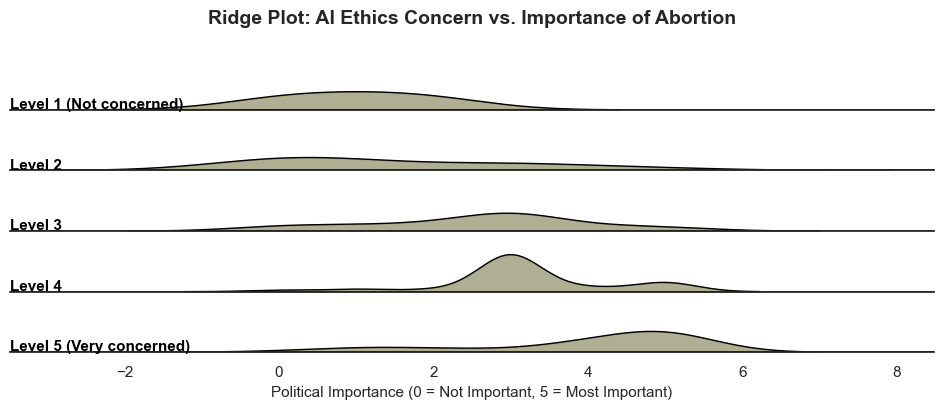

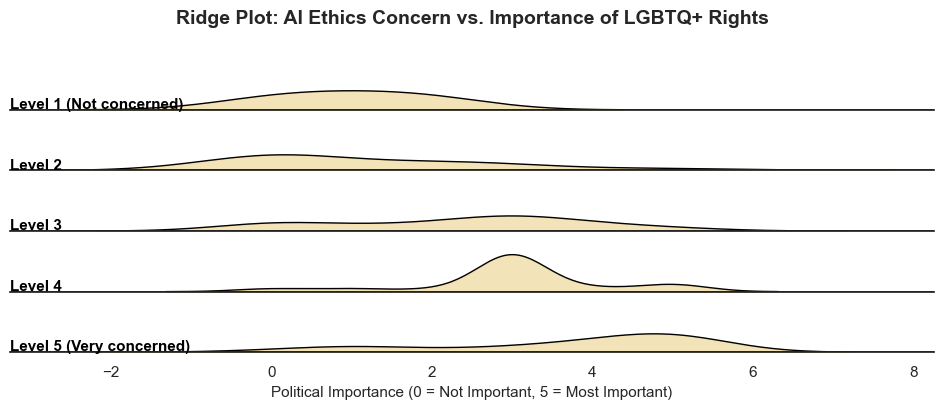

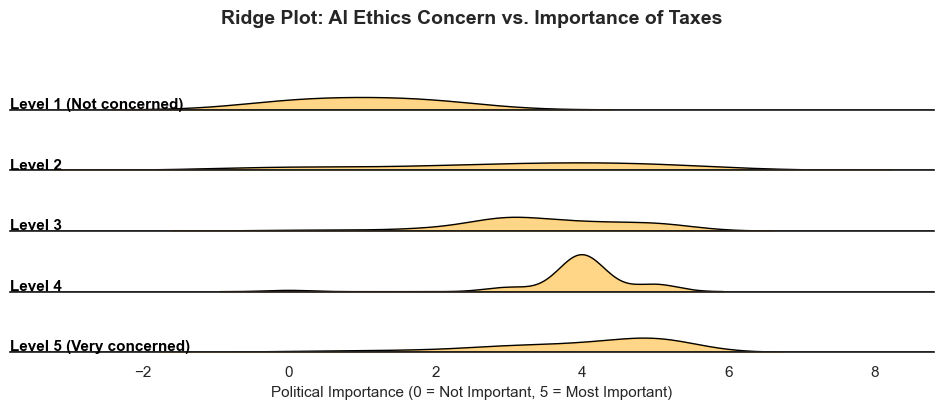

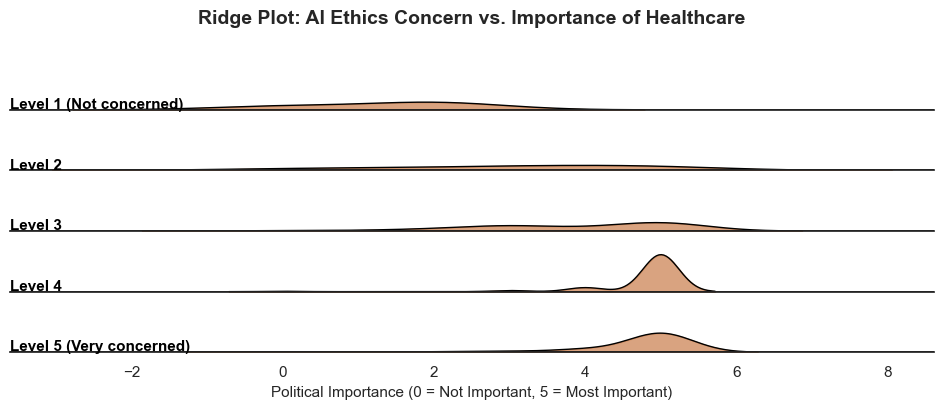

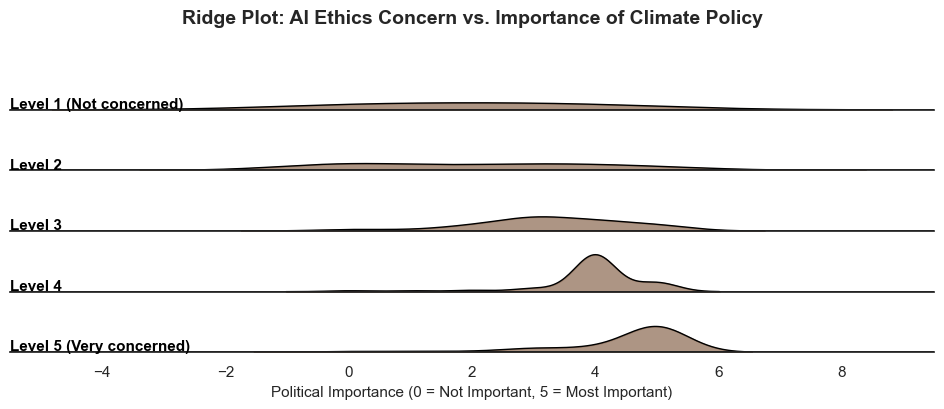

In [20]:
# I used the lab5-6 guide to make the ridge graph, as well as claude
# for cleaning the data

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = {
    'Immigration':   'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Abortion':      'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'LGBTQ+ Rights': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Taxes':         'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Healthcare':    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Climate Policy':'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
}

issue_colors = {
    'Immigration':   '#797D62',
    'Abortion':      '#9B9B7A',
    'LGBTQ+ Rights': '#F1DCA7',
    'Taxes':         '#FFCB69',
    'Healthcare':    '#D08C60',
    'Climate Policy':'#997B66',
}

ethics_labels = {
    1: 'Level 1 (Not concerned)',
    2: 'Level 2',
    3: 'Level 3',
    4: 'Level 4',
    5: 'Level 5 (Very concerned)',
}

ethics_order = list(ethics_labels.values())

rows = []
for label, col in political_cols.items():
    sub = df[[ethics_col, col]].dropna().copy()
    sub.columns = ['Ethics Concern', 'Political Importance']
    sub['Political Issue'] = label
    sub['Ethics Level'] = sub['Ethics Concern'].map(ethics_labels)
    rows.append(sub)

long_df = pd.concat(rows, ignore_index=True)
issues = list(political_cols.keys())

for issue in issues:
    issue_df = long_df[long_df['Political Issue'] == issue].copy()

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    g = sns.FacetGrid(
        issue_df,
        row="Ethics Level",
        hue="Ethics Level",
        aspect=12,
        height=0.8,
        palette=[issue_colors[issue]] * len(ethics_order),
        row_order=ethics_order,
        hue_order=ethics_order,
    )

    g.map(sns.kdeplot, "Political Importance", fill=True, alpha=0.8)
    g.map(sns.kdeplot, "Political Importance", color="black", linewidth=1)
    g.map(plt.axhline, y=0, linewidth=2, color="black")

    def label_ridge(x, color, label):
        ax = plt.gca()
        ax.text(0, 0.15, label, fontweight="bold", color="black",
                ha="left", va="center", transform=ax.transAxes, fontsize=11)

    g.map(label_ridge, "Political Importance")

    g.fig.suptitle(
        f"Ridge Plot: AI Ethics Concern vs. Importance of {issue}",
        fontsize=14, fontweight='bold', y=1.02
    )
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set_xlabels("Political Importance (0 = Not Important, 5 = Most Important)", fontsize=11)
    g.despine(left=True)

    plt.tight_layout()
   
    plt.show()

Details

Chi Square

In [18]:
from scipy.stats import chi2_contingency

df = pd.read_csv('data_cleaned_ethics_political.csv')

var1_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

var1 = pd.to_numeric(df[var1_col], errors='coerce')
political_df = df[political_cols].apply(pd.to_numeric, errors='coerce')
var2 = political_df.mean(axis=1)

# Bin var1 (1-5 scale, heavily skewed high) into 2 groups
# Low/Medium (1-3): 61 respondents | High (4-5): 165 respondents
var1_binned = pd.cut(var1, bins=[0.9, 3.5, 5], labels=['Low/Medium (1-3)', 'High (4-5)'])

# Bin var2 (average political importance, 0-5) into 3 groups
var2_binned = pd.cut(var2, bins=[-0.1, 2.5, 3.5, 5.1], labels=['Low (0-2.5)', 'Medium (2.5-3.5)', 'High (3.5-5)'])

contingency_table = pd.crosstab(var1_binned, var2_binned)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

Chi-Square Statistic: 80.97
P-value: 0.0000
Degrees of Freedom: 2


Chi-Square Statistic: 40.34
P-value: 0.0000

Result: Reject the Null Hypothesis.
Conclusion: There IS a statistically significant correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.